In [4]:
#%%
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, FuncFormatter, LogFormatterSciNotation
import numpy as np
import math
import json

In [5]:
"""
Results :

Red lines are plotted from metrics.json, which is the raw out put from their python experiments.
Their plots show a continuous, monotonically increasing recall plot line.
But when looking closely their code is sorting results from multiple graph builds first by y value (recall) then by x value (dist comp or latency).
This masks the issues with the raw output. 

In addition, running hnsw and flatnav with my C++ code using raw C++ library, with or without optimization matching, 
failed to reproduce consistent results.

"""

'\nResults :\n\nRed lines are plotted from metrics.json, which is the raw out put from their python experiments.\nTheir plots show a continuous, monotonically increasing recall plot line.\nBut when looking closely their code is sorting results from multiple graph builds first by y value (recall) then by x value (dist comp or latency).\nThis masks the issues with the raw output. \n\nIn addition, running hnsw and flatnav with my C++ code using raw C++ library, with or without optimization matching, \nfailed to reproduce consistent results.\n\n'

In [6]:
def loaddata(filename):
    arr = np.loadtxt(filename, delimiter=',', skiprows=1) # d,efc,m,efs,k,recall,distcountsearch
    return { # d,efc,m,efs,k,lp50,lp99,lave,dp50,dp99,dave,hp50,hp99,have,rp50,rp99,rave
        'd':                arr[:, 0],
        'efc':              arr[:, 1],
        'm':                arr[:, 2],
        'efs':              arr[:, 3],
        'k':                arr[:, 4],
        'lp50':             arr[:, 5],
        'lp99':             arr[:, 6],
        'lave':             arr[:, 7],
        'dp50':             arr[:, 8],
        'dp99':             arr[:, 9],
        'dave':             arr[:, 10],
        'hp50':             arr[:, 11],
        'hp99':             arr[:, 12],
        'have':             arr[:, 13],
        'rp50':             arr[:, 14],
        'rp99':             arr[:, 15],
        'recall':           arr[:, 16],
    }

In [39]:
def plot(datasets, metrics_file_path):
    # 1 dataset per set
    for dataset_name, dataset_fullname in datasets.items():

        # load metric.json
        with open(metrics_file_path, "r") as file:
                metrics_json = json.load(file)

        # 1 param per graph
        metrics = {
            "lp50" : "latency_p50",
            "lp99" : "latency_p99",
            "dave" : "distance_computations",
        }

        # 1 run per line >> select/load data for each line
        data = {}
        for key, value in metrics_json.items():
            if dataset_name in key and "flatnav" in key and "base" not in key:
                data["flatnav-off"] = value
            elif dataset_name in key and "base" in key:
                data["flatnav-hnsw-base-off"] = value
            elif dataset_name in key and "hnsw" in key and "base" not in key:
                data["hnsw-off"] = value

        # data["hnsw-mine-opt"] = loaddata(f"data/hnsw-n-{dataset_fullname}-opt.txt")
        # data["hnsw-mine"] = loaddata(f"data/hnsw-n-{dataset_fullname}.txt")
        # data["flatnav-mine-opt"] = loaddata(f"data/flatnav-{dataset_fullname}-opt.txt")
        # data["flatnav-mine"] = loaddata(f"data/flatnav-{dataset_fullname}.txt")
        
        linecolor = [
            "#fc032c",
            "#b50db2",
            "#f06800",
            "#3600e6",
            "#00bfe6",
            "#42f5aa",
            "#0c6b43",
        ]
        lineweight = 0.7
        linestyle = '-'
        marker = 'x'
        
        # 1 plot for each param
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        for (key, value), ax in zip(metrics.items(), (ax1, ax2, ax3)):

            # set x 
            xkey = "recall"

            # for each run = each line
            for (run, run_data), color in zip(data.items(), linecolor):

                # A. plot from json
                if "-off" in run:
                    ykey = value

                    # define x array
                    x = [item[xkey] for item in run_data]
                    # define y array
                    y = [item[ykey] for item in run_data]
                    
                # B. plot from .txt
                else:
                    ykey = key

                    # define x array
                    x = run_data[xkey]
                    # define y array
                    y = run_data[ykey]

                # plot
                ax.plot(x, y, marker=marker, color=color, label=run, alpha=lineweight, linestyle=linestyle)

            plottitle = f'{dataset_name}_{value}'

            ax.set_xlabel('Recall')
            ax.set_ylabel(value)
            ax.set_title(plottitle)
            ax.legend()

            # save
        fig.tight_layout()
        fig.savefig(f'{plottitle}.png', dpi=300, bbox_inches='tight')

In [40]:
# plot full optimization matching results
datasets = {
    'deep': "deep-image-96-angular",
    # 'gist',
    # 'glove-100',
    # 'glove-200',
    # 'mnist',
    # 'nytimes',
    'sift': "sift-128-euclidean",
}

metrics_file_path = "metrics/metrics.json"

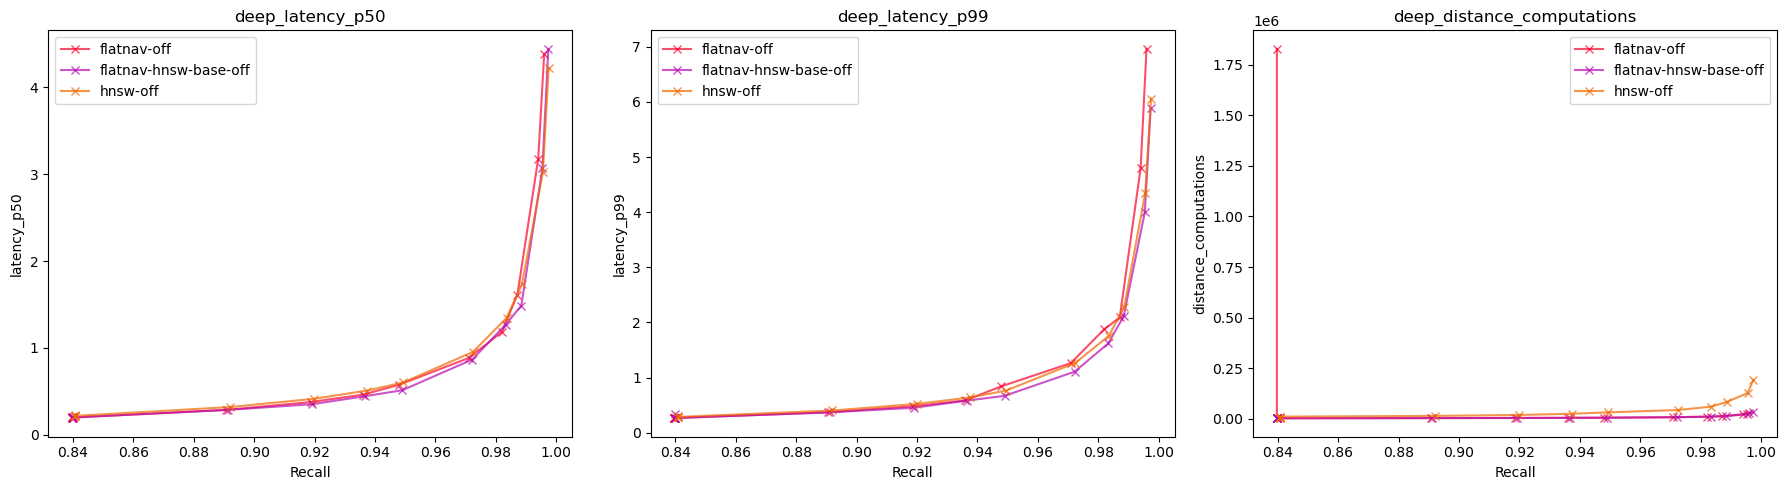

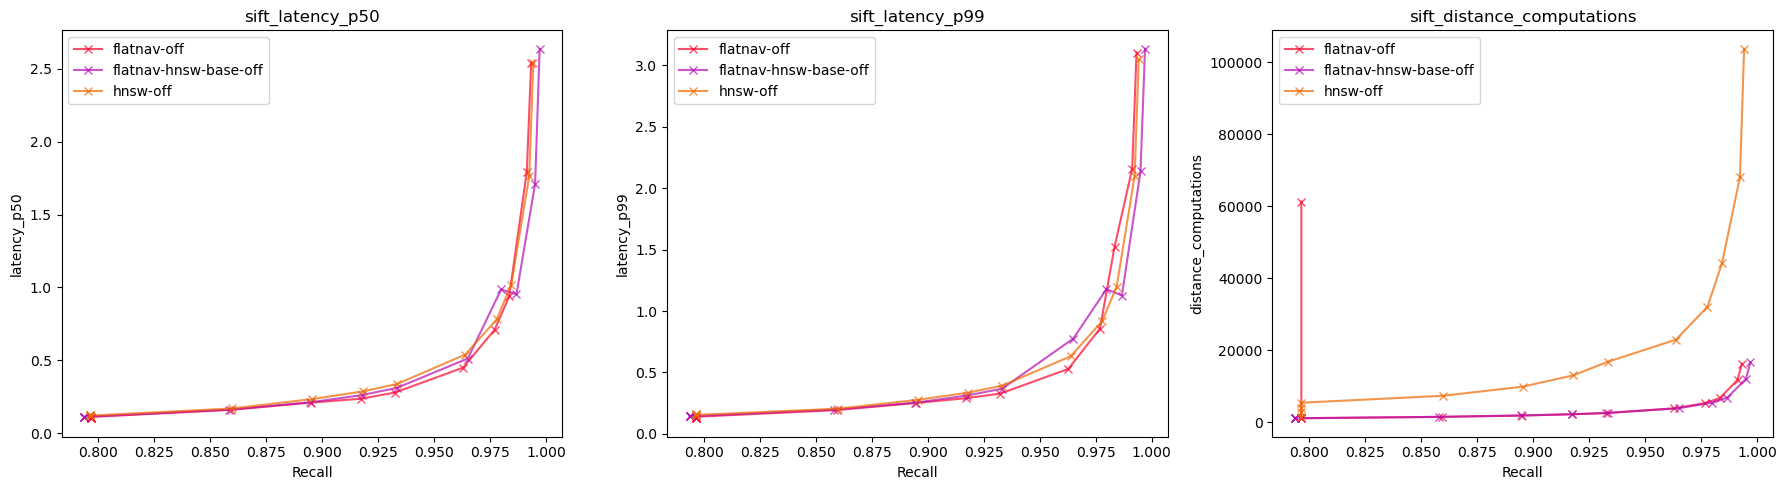

In [41]:
plot(datasets, metrics_file_path)